In [77]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append("../election_data_cleaning")
from jp_eng_dicts import jp_prefect_to_eng


In [78]:
df = pd.read_csv("../../../data/raw/foreign population in japan over time 2012-2024.csv", skiprows=1)

In [45]:
df.head()

,時点,全国,北海道,青森県,岩手県,宮城県,秋田県,山形県,福島県,茨城県,...,愛媛県,高知県,福岡県,佐賀県,長崎県,熊本県,大分県,宮崎県,鹿児島県,沖縄県
0,2012年,2033656,22027,3930,5372,14214,3702,6214,9259,50562,...,8905,3380,53356,4360,7289,9110,9908,4125,6317,9404
1,2013年,2066445,22629,3975,5505,15247,3714,6182,9726,51107,...,8834,3428,56437,4387,7995,9693,9862,4262,6443,10198
2,2014年,2121831,23534,4041,5697,16274,3622,6131,10249,52009,...,9290,3565,57696,4401,8295,10079,10234,4414,6733,11229
3,2015年,2232189,25692,4245,5902,17708,3616,6160,11052,54095,...,10279,3728,60417,4605,10979,10767,10573,4616,7222,12925
4,2016年,2382822,28869,4568,6275,19314,3695,6378,12068,58182,...,11020,3997,64998,5203,11735,11662,11149,5100,7954,14285


In [79]:
#rename columns
df = df.rename(columns = jp_prefect_to_eng)
df = df.rename(columns = {'時点': 'year', '全国':'Japan'})
df['year'] = [pd.to_datetime(x.replace('年', ''), format='%Y') for x in df['year']]
#df.index = [pd.to_datetime(x.replace('年', ''), format='%Y') for x in df.index]


In [105]:
df.head()

,year,Japan,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
0,2012-01-01,2033656,22027,3930,5372,14214,3702,6214,9259,50562,...,8905,3380,53356,4360,7289,9110,9908,4125,6317,9404
1,2013-01-01,2066445,22629,3975,5505,15247,3714,6182,9726,51107,...,8834,3428,56437,4387,7995,9693,9862,4262,6443,10198
2,2014-01-01,2121831,23534,4041,5697,16274,3622,6131,10249,52009,...,9290,3565,57696,4401,8295,10079,10234,4414,6733,11229
3,2015-01-01,2232189,25692,4245,5902,17708,3616,6160,11052,54095,...,10279,3728,60417,4605,10979,10767,10573,4616,7222,12925
4,2016-01-01,2382822,28869,4568,6275,19314,3695,6378,12068,58182,...,11020,3997,64998,5203,11735,11662,11149,5100,7954,14285


In [ ]:
def calc_yearly_inc(x):
    yearly_inc = []
    for i in range(len(x)):
        if i == 0:
            j = 0
        else:
            j = i - 1
        inc = (x[i]-x[j]) / x[j]
        yearly_inc.append(inc)
    return yearly_inc


In [81]:
df_yearly_inc = df.copy()

In [82]:
for column in df_yearly_inc.columns[1:]:
    df_yearly_inc[column] = calc_yearly_inc(df_yearly_inc[column])

In [115]:
df_yearly_inc.describe().loc['mean']

Japan        0.049707
Hokkaido     0.094889
Aomori       0.064774
Iwate        0.062229
Miyagi       0.060808
Akita        0.037652
Yamagata     0.043151
Fukushima    0.062757
Ibaraki      0.057073
Tochigi      0.051218
Gunma        0.056581
Saitama      0.064223
Chiba        0.063356
Tokyo        0.051151
Kanagawa     0.047092
Niigata      0.050209
Toyama       0.047088
Ishikawa     0.055142
Fukui        0.039339
Yamanashi    0.040302
Nagano       0.031407
Gifu         0.039459
Shizuoka     0.038087
Aichi        0.042161
Mie          0.037965
Shiga        0.044303
Kyoto        0.039160
Osaka        0.039789
Hyogo        0.030646
Nara         0.044203
Wakayama     0.045168
Tottori      0.035183
Shimane      0.056777
Okayama      0.050037
Hiroshima    0.046052
Yamaguchi    0.038449
Tokushima    0.047742
Kagawa       0.070751
Ehime        0.061821
Kochi        0.057958
Fukuoka      0.061448
Saga         0.080631
Nagasaki     0.068877
Kumamoto     0.097923
Oita         0.061313
Miyazaki  

In [ ]:
means = df_yearly_inc.describe().loc['mean','Japan':'Okinawa']
means.sort_values(inplace=True)

Index(['Hyogo', 'Nagano', 'Tottori', 'Akita', 'Mie', 'Shizuoka', 'Yamaguchi',
       'Kyoto', 'Fukui', 'Gifu', 'Osaka', 'Yamanashi', 'Aichi', 'Yamagata',
       'Nara', 'Shiga', 'Wakayama', 'Hiroshima', 'Toyama', 'Kanagawa',
       'Tokushima', 'Japan', 'Okayama', 'Niigata', 'Tokyo', 'Tochigi',
       'Ishikawa', 'Gunma', 'Shimane', 'Ibaraki', 'Kochi', 'Miyagi', 'Oita',
       'Fukuoka', 'Ehime', 'Iwate', 'Fukushima', 'Chiba', 'Saitama', 'Aomori',
       'Nagasaki', 'Kagawa', 'Saga', 'Miyazaki', 'Kagoshima', 'Okinawa',
       'Hokkaido', 'Kumamoto'],
      dtype='object')

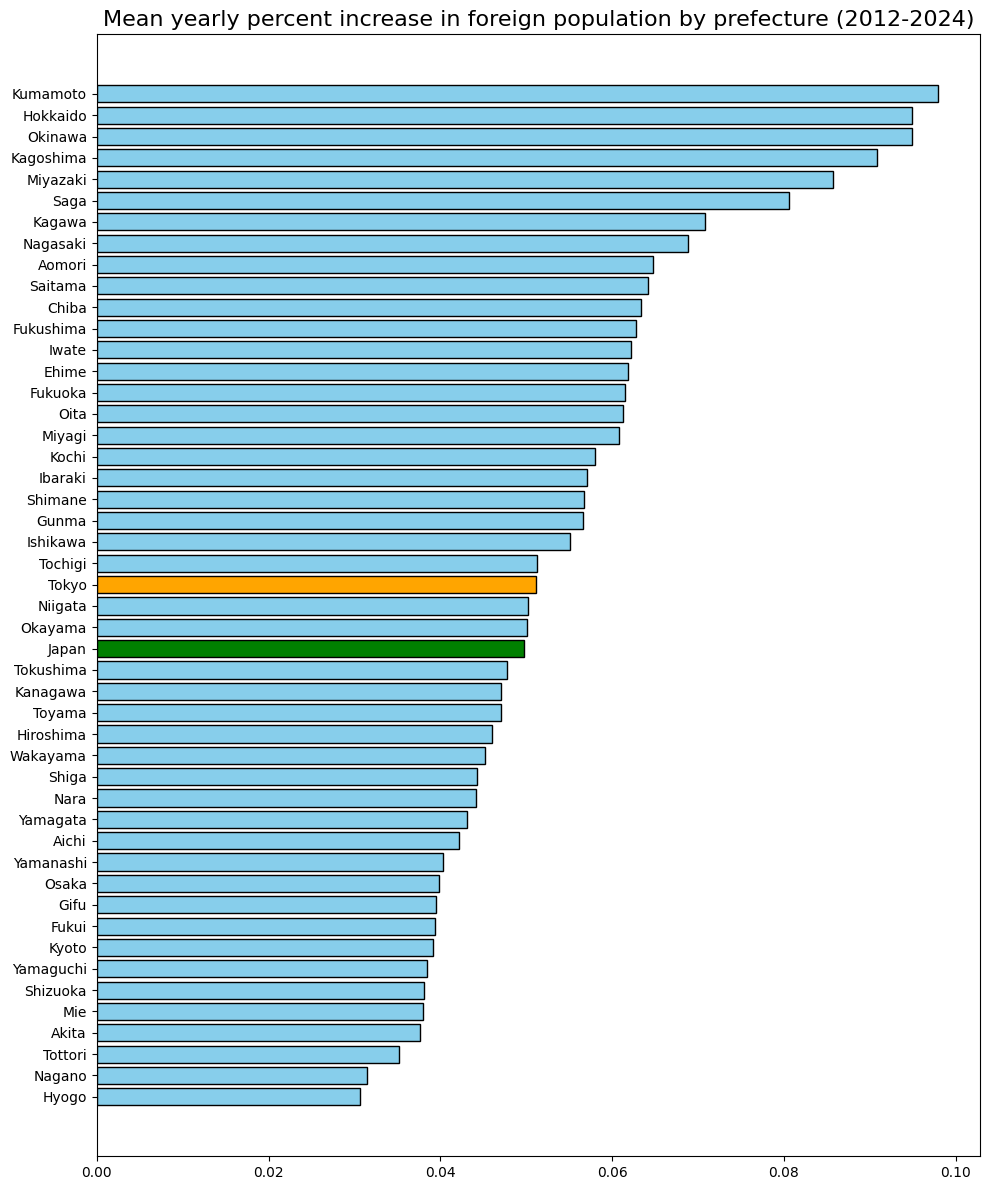

In [142]:
#plt.bar(means.index, means)
highlight = {'Tokyo':'orange', 'Japan':'green'}
colors = [highlight.get(name, 'skyblue') for name in means.index]

fig, ax = plt.subplots(figsize=(10,12))
ax.barh(means.index, means, color = colors, edgecolor='black')
ax.set_title('Mean yearly percent increase in foreign population by prefecture (2012-2024)', fontsize=16)
#ax.set_ylabel('Mean yearly increase')
#ax.set_xticks(range(len(means.index)))
#ax.set_xticklabels(means.index, rotation=90)
fig.tight_layout()
plt.show()


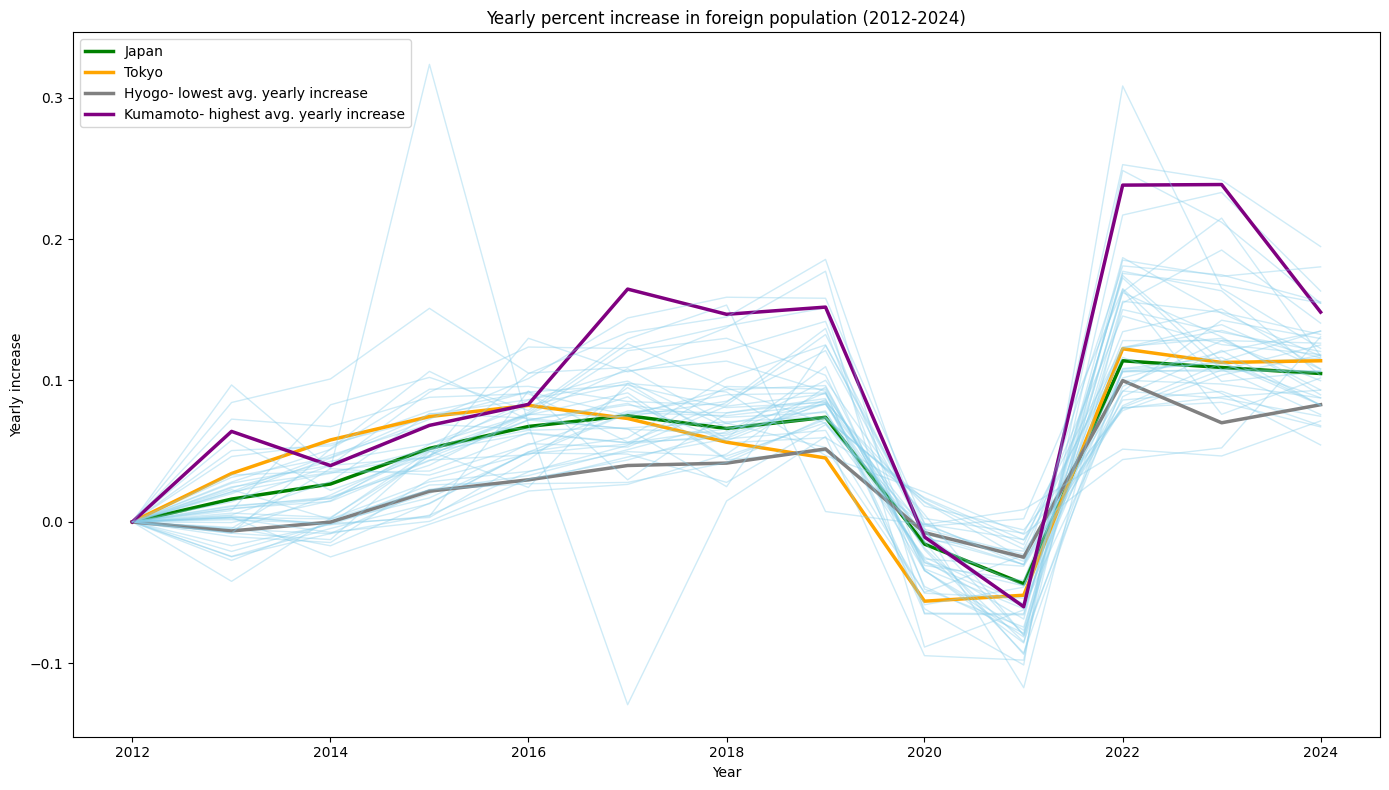

In [132]:
fig, ax = plt.subplots(figsize=(14,8))
highlight = ['Japan', 'Tokyo']
for prefecture in df_yearly_inc.columns:
    if prefecture == 'Japan':
        ax.plot(
            df_yearly_inc.index,
            df_yearly_inc[prefecture],
            label = prefecture,
            linewidth = 2.5,
            alpha = 1.0,
            color = 'green'
        )
    elif prefecture == 'Tokyo':
        ax.plot(
            df_yearly_inc.index,
            df_yearly_inc[prefecture],
            label = prefecture,
            linewidth = 2.5,
            alpha = 1.0,
            color = 'orange'
        )
    elif prefecture == 'Kumamoto':
        ax.plot(
            df_yearly_inc.index,
            df_yearly_inc[prefecture],
            label = prefecture + '- highest avg. yearly increase',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'purple'
        )
    elif prefecture == 'Hyogo':
        ax.plot(
            df_yearly_inc.index,
            df_yearly_inc[prefecture],
            label = prefecture + '- lowest avg. yearly increase',
            linewidth = 2.5,
            alpha = 1.0,
            color = 'grey'
        )
    else:
        ax.plot(
            df_yearly_inc.index,
            df_yearly_inc[prefecture],
            label = '_nolegend',
            linewidth = 1,
            alpha = 0.4,
            color = 'skyblue'
        )
ax.set_title('Yearly percent increase in foreign population (2012-2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Yearly increase')
ax.legend(loc='upper left', fontsize='medium')
fig.tight_layout()

In [135]:
df.set_index('year', inplace=True)

In [136]:
df.head()

,Japan,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,Tochigi,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
year,,,,,,,,,,,,,,,,,,,,,
2012-01-01,2033656,22027,3930,5372,14214,3702,6214,9259,50562,30087,...,8905,3380,53356,4360,7289,9110,9908,4125,6317,9404
2013-01-01,2066445,22629,3975,5505,15247,3714,6182,9726,51107,30727,...,8834,3428,56437,4387,7995,9693,9862,4262,6443,10198
2014-01-01,2121831,23534,4041,5697,16274,3622,6131,10249,52009,32178,...,9290,3565,57696,4401,8295,10079,10234,4414,6733,11229
2015-01-01,2232189,25692,4245,5902,17708,3616,6160,11052,54095,34402,...,10279,3728,60417,4605,10979,10767,10573,4616,7222,12925
2016-01-01,2382822,28869,4568,6275,19314,3695,6378,12068,58182,36654,...,11020,3997,64998,5203,11735,11662,11149,5100,7954,14285


In [137]:
df_yearly_inc.head()

,Japan,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,Tochigi,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
year,,,,,,,,,,,,,,,,,,,,,
2012-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-01-01,0.016123,0.027330,0.011450,0.024758,0.072675,0.003241,-0.00515,0.050437,0.010779,0.021272,...,-0.007973,0.014201,0.057744,0.006193,0.096858,0.063996,-0.004643,0.033212,0.019946,0.084432
2014-01-01,0.026803,0.039993,0.016604,0.034877,0.067358,-0.024771,-0.00825,0.053773,0.017649,0.047222,...,0.051619,0.039965,0.022308,0.003191,0.037523,0.039823,0.037721,0.035664,0.045010,0.101098
2015-01-01,0.052011,0.091697,0.050483,0.035984,0.088116,-0.001657,0.00473,0.078349,0.040108,0.069116,...,0.106459,0.045722,0.047161,0.046353,0.323568,0.068261,0.033125,0.045763,0.072627,0.151037
2016-01-01,0.067482,0.123657,0.076090,0.063199,0.090693,0.021847,0.03539,0.091929,0.075552,0.065461,...,0.072089,0.072157,0.075823,0.129859,0.068859,0.083124,0.054478,0.104853,0.101357,0.105222


In [139]:
df.to_csv("../../data/clean/immigration_data/foreign_resident_pop_2012-2024.csv")

In [140]:
df_yearly_inc.to_csv("../../data/clean/immigration_data/foreign_resident_yearly_inc_2012-2024.csv")